In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete, Predictive, Importance, EmpiricalMarginal
from pyro.infer.mcmc.mcmc_kernel import MCMCKernel
from pyro.ops.indexing import Vindex
from pyro import poutine
from pyro.poutine import trace, replay

In [3]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  
from functools import reduce
from tqdm import trange

In [4]:
 def generalized_einsum(tensor_a, tensor_b):
    # Get shapes
    shape_a = tensor_a.shape  # e.g., (n, a1, a2, a3, a4, ...)
    shape_b = tensor_b.shape  # e.g., (..., k) = (a4, a3, a2, a1, k)
    
    # Extract n (first dimension of A)
    n = shape_a[0]
    
    # Extract additional dimensions from A (excluding n)
    dims_a = list(shape_a[1:])  # e.g., [a1, a2, a3, a4]
    
    # Extract dimensions from B (excluding k)
    dims_b = list(shape_b[:-1])  # e.g., [a4, a3, a2, a1]
    k = shape_b[-1]
    
    # Validate that B's dimensions (excluding k) are the reverse of A's (excluding n)
    if dims_a != dims_b[::-1]:
        raise ValueError(f"Dimensions {dims_a} and {dims_b} are not compatible (must be reverse order)")
    
    # Create dimension labels
    # Use unique letters for each dimension (e.g., i, j, k, l for a1, a2, a3, a4)
    dim_labels = [chr(105 + i) for i in range(len(dims_a))]  # e.g., ['i', 'j', 'k', 'l']
    
    # Pattern for A: n followed by additional dims
    pattern_a = f"a {' '.join(dim_labels)}"  # e.g., "n i j k l"
    
    # Pattern for B: reversed additional dims followed by k
    pattern_b = f"{' '.join(dim_labels[::-1])} z"  # e.g., "l k j i k"
    
    # Output pattern: n k
    pattern_out = "a z"
    
    # Full einsum pattern
    pattern = f"{pattern_a}, {pattern_b} -> {pattern_out}"  # e.g., "n i j k l, l k j i k -> n k"
    
    # Perform einsum
    return einops.einsum(tensor_a, tensor_b, pattern)

In [5]:
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = (1 - beta).cumprod(dim=-1)
    # Pad beta with a 1 at the end of the last dimension
    beta_padded = F.pad(beta, (0, 1), value=1)
    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = F.pad(beta1m_cumprod, (1, 0), value=1)
    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded
    rlt = torch.max(weight, torch.tensor(1e-6, device=beta.device))
    rlt = rlt/rlt.sum(dim=-1, keepdim=True)
    # return F.softmax(beta_padded * beta1m_cumprod_padded, dim=-1)
    return rlt
    

In [78]:
def model(data, struct_upbd, vocab_size, device):

    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    
    # model parameters
    struct_params = {}
    struct_params["gamma"] = pyro.param("model_gamma", torch.rand(1, device=device), constraint=constraints.positive)

    struct_params["nig_mu"] = pyro.param("model_nig_mu", torch.zeros(1, device=device))
    struct_params["nig_kappa"] = pyro.param("model_nig_kappa", torch.ones(1, device=device), constraint=constraints.positive)
    struct_params["nig_alpha"] = pyro.param("model_nig_alpha", torch.ones(1, device=device), constraint=constraints.positive)
    struct_params["nig_beta"] = pyro.param("model_nig_beta", torch.ones(1, device=device), constraint=constraints.positive)
    
    for parent_level in range(len(struct_upbd)-1):  
        child_level = parent_level + 1
        struct_params[f"alpha{parent_level}"] = pyro.param(f"model_alpha{parent_level}", torch.rand(param_dims[-child_level:-1], device=device) , constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-child_level:])
        assert struct_params[f"alpha{parent_level}"].shape == tuple(param_dims[-child_level:])

        struct_params[f"eta{parent_level}"] = pyro.param(f"model_eta{parent_level}", torch.rand(param_dims[-child_level:-1], device=device), constraint=constraints.positive)
        assert struct_params[f"eta{parent_level}"].shape == tuple(param_dims[-child_level:-1])
    struct_params[f"alpha{len(struct_upbd)-1}"] = pyro.param(f"model_alpha{len(struct_upbd)-1}", torch.rand(param_dims[-len(struct_upbd)+1:-1], device=device), constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-len(struct_upbd)+1:])

    # struct_params["reg_mu_mu"] = pyro.param("model_reg_mu_mu", torch.zeros([struct_upbd["G0"],], device=device))
    # struct_params["reg_mu_sigma"] = pyro.param("model_reg_mu_sigma", torch.ones([struct_upbd["G0"],], device=device), constraint=constraints.positive)
    # struct_params["reg_sigma"] = pyro.param("model_reg_sigma", torch.ones([struct_upbd["G0"],], device=device), constraint=constraints.positive)

    # model structures
    struct_weights = {}
    struct_weights["B0"] = (torch.ones(1, device=device).expand(param_dims[-1:]), struct_params["gamma"].expand(param_dims[-1:]))
    struct_samples = {}
    beta_0 = pyro.sample("G0", dist.Beta(struct_weights["B0"][0], struct_weights["B0"][1]).to_event(1))
    struct_samples["B0"] = beta_0
    assert beta_0.shape == (param_dims[-1], )

    struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
    assert struct_weights["G0"].shape == (param_dims[-1], )

    for parent_level in range(len(struct_upbd)-1):
        child_level = parent_level + 1
        full_dim = child_level + 1

        param_alpha = struct_params[f"alpha{parent_level}"]*struct_weights[f"G{parent_level}"]
        param_beta = struct_params[f"alpha{parent_level}"]*(1 - struct_weights[f"G{parent_level}"].cumsum(-1))
        struct_weights[f"B{child_level}"] = (param_alpha.unsqueeze(0).expand(param_dims[-full_dim:]), param_beta.unsqueeze(0).expand(param_dims[-full_dim:]))
        beta = pyro.sample(f"G{child_level}", dist.Beta(struct_weights[f"B{child_level}"][0], struct_weights[f"B{child_level}"][1]).to_event(child_level))
        struct_samples[f"B{child_level}"] = beta
        struct_weights[f"G{child_level}"] = mix_weights(beta)[..., :-1]
        assert struct_weights[f"G{child_level}"].shape == tuple(param_dims[-full_dim:])

    cluster_weights = {}
    cluster_samples = {}
    for parent_level in range(len(struct_upbd)-1):
        child_level = parent_level + 1
        full_dim = child_level + 1
        beta = pyro.sample(f"L{parent_level}", dist.Beta(torch.ones_like(struct_params[f"eta{parent_level}"], device=device).unsqueeze(0).expand(param_dims[-full_dim:-1]), struct_params[f"eta{parent_level}"].unsqueeze(0).expand(param_dims[-full_dim:-1])).to_event(child_level))
        cluster_samples[f"B{parent_level}"] = beta
        assert beta.shape == tuple(param_dims[-full_dim:-1])
        cluster_weights[f"L{parent_level}"] = mix_weights(beta)[..., :-1]

    mixture_components = {}
    mixture_components["generation"] = pyro.sample(f"gen", dist.Dirichlet(struct_params["gamma"] * torch.ones(vocab_size, device=device).unsqueeze(0).expand(struct_upbd["G0"], vocab_size)).to_event(1))
    mixture_components["regression_sigma"] = pyro.sample(f"regression_sigma", dist.InverseGamma(struct_params["nig_alpha"].expand(param_dims[-1:]), struct_params["nig_beta"].expand(param_dims[-1:])).to_event(1))
    mixture_components["regression_mu"] = pyro.sample(f"regression_mu", dist.Normal(struct_params["nig_mu"].expand(param_dims[-1:]), torch.sqrt(mixture_components["regression_sigma"] / struct_params["nig_kappa"].expand(param_dims[-1:]))).to_event(1))
    

    # data fitting
    if (data[0] is not None):
        feature = data[0].to(device)
        N = feature.shape[0]
        M = feature.shape[1]
    else:
        feature = data[0]
        N = 50
        M = 200

    if data[1] is not None:
        label = data[1].to(device)
    else:
        label = data[1]

    assigned_zs = [torch.zeros(N, device=device, dtype=torch.long)]
    doc_weights = {}
    with pyro.plate("Data", N):
        for level in range(len(struct_upbd)-1):
            param = cluster_weights[f"L{level}"].unsqueeze(0)[assigned_zs[:]]
            assigned_zs.append(pyro.sample(f"z{level}", dist.Categorical(param)))

        assigned_zs.reverse()
        weights_prior = struct_weights[f"G{len(struct_upbd)-1}"][assigned_zs[:-1]]
        concentrate = struct_params[f"alpha{len(struct_upbd)-1}"][assigned_zs[:-1]].unsqueeze(-1)

        param_alpha = concentrate*weights_prior
        param_beta = concentrate*(1 - weights_prior.cumsum(-1))
        beta = pyro.sample(f"g", dist.Beta(param_alpha, param_beta).to_event(1))

        doc_weights["BP"] = [param_alpha, param_beta]
        doc_weights["B"] = beta

        assert beta.shape == (N, struct_upbd["G0"])
        topic_dist = mix_weights(beta)[..., :-1]
        doc_weights["G"] = topic_dist

        topic_over_docs = topic_dist.unsqueeze(1).expand(-1, M, -1)
        z_gen = pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(probs=topic_over_docs).to_event(1))
        word_dists = mixture_components["generation"][z_gen]  
        obs = pyro.sample("u", dist.Multinomial(1, probs=word_dists).to_event(1), obs=feature)

        z_reg = pyro.sample(f"z{len(struct_upbd)+1}", dist.Categorical(probs=topic_dist))
        reg_mu = mixture_components["regression_mu"][z_reg]
        reg_sigma = mixture_components["regression_sigma"][z_reg]
        reg = pyro.sample("y", dist.Normal(reg_mu, reg_sigma), obs=label)

    cat_zs = assigned_zs[: -1]
    cat_zs.reverse()

    return {
        "struct_params": struct_params,
        "struct_weights": struct_weights,
        "struct_samples": struct_samples,
        "cluster_weights": cluster_weights,
        "cluster_samples": cluster_samples,
        "mixture_components": mixture_components,
        "category_assignments": torch.stack(cat_zs, dim=1),
        "doc_weights": doc_weights,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs, 
            "reg": reg
        }
    }

In [7]:
def compute_log_likelihood(model_return):

    log_likelihood = 0.0

    # Compute log likelihood for each document
    for data_idx in range(model_return["words"]["z_gen"].shape[0]):
        # Get the topic assignments and word observations for the current document
        topic_assignments = model_return["words"]["z_gen"][data_idx]
        word_obs = model_return["words"]["obs"][data_idx]
        doc_log_probs = []
        for word_idx in range(len(word_obs)):
            topic = topic_assignments[word_idx]
            word_log_prob = dist.Multinomial(1, model_return["mixture_components"]["generation"][topic]).log_prob(word_obs[word_idx])
            doc_log_probs.append(word_log_prob)
        log_likelihood += sum(doc_log_probs).item()
        reg_z = model_return["words"]["z_reg"][data_idx]
        reg = model_return["words"]["reg"][data_idx]
        reg_log_prob = dist.Normal(model_return["mixture_components"]["regression_mu"][reg_z], model_return["mixture_components"]["regression_sigma"][reg_z]).log_prob(reg)
        log_likelihood += sum(reg_log_prob).item()
    
    assert isinstance(log_likelihood, float)

    return log_likelihood

In [8]:
def generate_distinct_components(K, V, peak_strength=5.0, base_concent=0.1):
    comps = []
    for k in range(K):
        alpha = torch.ones(V) * base_concent
        alpha[k * V // K] = peak_strength
        comp = torch.distributions.Dirichlet(alpha).sample()
        comps.append(comp)
    return torch.stack(comps)  # shape: (K, V)


In [9]:
def generate_distinct_distributions(N, V, concent=0.8):
    dists = []
    alpha = torch.ones(V) * concent  # sparse
    alpha = torch.clamp(alpha, min=1e-6)
    dist = torch.distributions.Dirichlet(alpha)
    samples = dist.sample((N,))
    return samples


In [10]:
def select_most_diverse(samples, num_select=3):
    """
    samples: (N, D) tensor of N samples with dimension D
    num_select: how many to select
    """
    N = samples.size(0)
    selected = [0]  # start with first sample arbitrarily

    # Compute full pairwise distance matrix (Euclidean)
    # dist[i,j] = ||samples[i] - samples[j]||_2
    diff = samples.unsqueeze(1) - samples.unsqueeze(0)  # (N, N, D)
    dist_matrix = torch.norm(diff, dim=2)  # (N, N)

    for _ in range(num_select - 1):
        # distances from all samples to selected set
        dist_to_selected = dist_matrix[selected, :]  # shape: (len(selected), N)
        min_dist_to_selected, _ = dist_to_selected.min(dim=0)  # min distance to any selected sample

        # Mask out already selected indices by setting distance to -1
        min_dist_to_selected[selected] = -1

        # Pick sample with max min distance
        next_idx = torch.argmax(min_dist_to_selected).item()
        selected.append(next_idx)

    return selected

In [11]:
def js_divergence(p, q, eps=1e-9):
    """
    p, q: [..., V] probability vectors (last dim sums to 1)
    returns: JS divergence (same batch shape as p[..., 0])
    """
    p = p.clamp_min(eps)
    q = q.clamp_min(eps)
    m = 0.5 * (p + q)
    kl_pm = (p * (p.log() - m.log())).sum(-1)
    kl_qm = (q * (q.log() - m.log())).sum(-1)
    return 0.5 * (kl_pm + kl_qm)

In [12]:
def generate_hierarchical_mixture_data(struct_upbd,
    N_per_base=20, M=200, V=100,  # N_per_base: number of samples per base category
    seed=42
):
    # Config
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base
    torch.manual_seed(seed)

    y_means = torch.linspace(-num_features/4, num_features/4, steps=num_features)
    y_stds = 0.1 + 0.1 * torch.rand(num_features)

    alpha_1 = 0.8
    assert (num_features >= num_base_per_super*num_super)
    super_window = int(num_features/ num_super)
    super_core = generate_distinct_distributions(num_super, super_window, alpha_1)

    row_idx = torch.arange(num_super*super_window).reshape(num_super, super_window)  # (m, k)
    super_prototypes = torch.zeros(num_super, num_features, dtype=super_core.dtype)
    blocks = int(num_features/super_window)
    for i in range(blocks):
        super_prototypes[:, i*super_window:(i+1)*super_window] = super_core * (i == torch.arange(num_super) % blocks).unsqueeze(1)
    super_prototypes = super_prototypes / super_prototypes.sum(dim=-1, keepdim=True)
    
    
    base_prototypes = []
    alpha_2 = [6, 8]
    for super_id in range(num_super):
        candids = generate_distinct_distributions(num_base_per_super*5, num_features, alpha_2[super_id]*super_prototypes[super_id])
        base_prototypes.append(candids[select_most_diverse(candids, num_base_per_super)])
        # base_prototypes.append(generate_distinct_distributions(num_base_per_super, num_features, alpha_2[super_id]*super_prototypes[super_id]))
    base_prototypes = torch.stack(base_prototypes)

    eta=1
    word_dists = generate_distinct_components(num_features, V, base_concent=eta)
    word_block = int(V / (num_super*num_base_per_super))
    overlap = int(word_block/2)
    for i in range(num_features):
        overlap_start = 0
        if (i < int(num_features / 2)):
            non_zero_idxs = torch.arange(i*overlap, i*overlap + word_block)
        else:
            non_zero_idxs = torch.arange(-(i*overlap + word_block)-1, -i*overlap -1)
        mask = torch.zeros(V, dtype=torch.bool)
        mask[non_zero_idxs] = True
        word_dists[i] = word_dists[i]*mask
    word_dists = word_dists / word_dists.sum(dim=-1, keepdim=True)
    X = []
    y = []
    labels_base = []
    labels_super = []
    
    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id*num_base_per_super + base_offset
            base_proto = base_prototypes[super_id][base_offset]
            
            for _ in range(samples_per_base):
                noise = torch.randn(num_features) * 0.1  # local noise around base proto
                doc_dist = base_proto
    
                doc = []
                for word_id in range(M):
                    comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                    word = torch.distributions.Multinomial(1, word_dists[comp_id]).sample()
                    doc.append(word)
                doc = torch.stack(doc)
                
                X.append(doc)
                comp_id = torch.distributions.Categorical(doc_dist).sample().item()
                y.append(torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,)))
                labels_base.append(base_id)
                labels_super.append(super_id)
    
    X_data = torch.stack(X)
    y_data = torch.stack(y)
    labels_base = torch.tensor(labels_base)
    labels_super = torch.tensor(labels_super)    

    return {
        "x": X_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes     # (num_super*num_base_per_super, 
        
    }


In [13]:
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data(struct_upbd)
# Aggregate bag-of-words sequences by summing over M dimension
  # (total_data, V)
x_agg = data["x"].sum(dim=1)

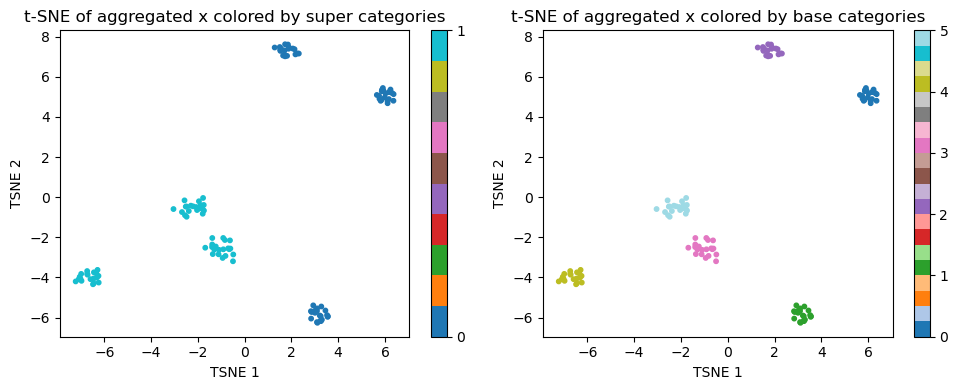

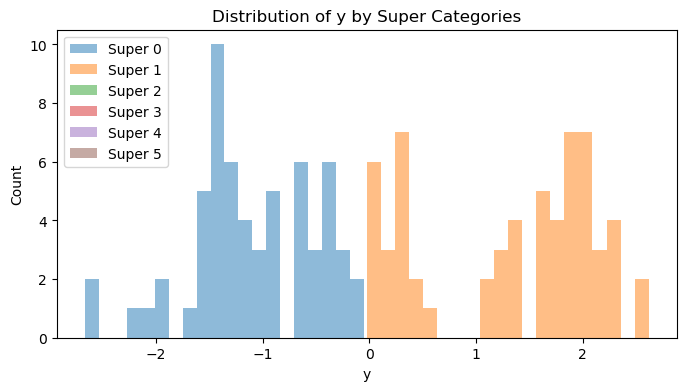

In [14]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(6):
    y_vals = data["y"][data["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


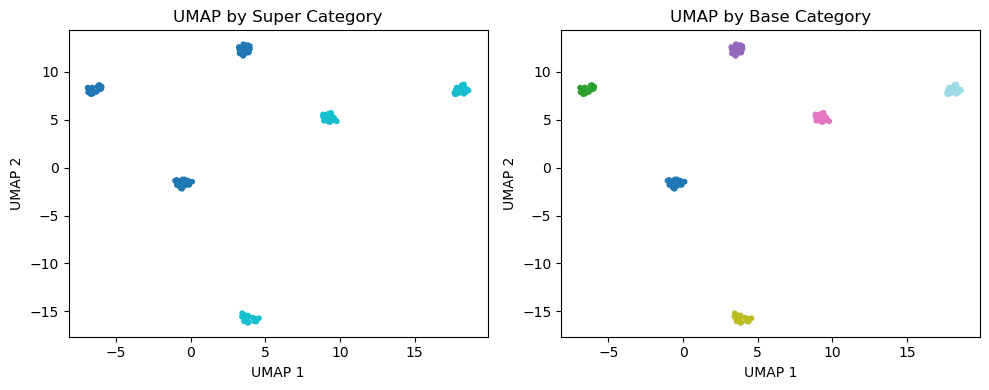

torch.Size([2, 3, 10])


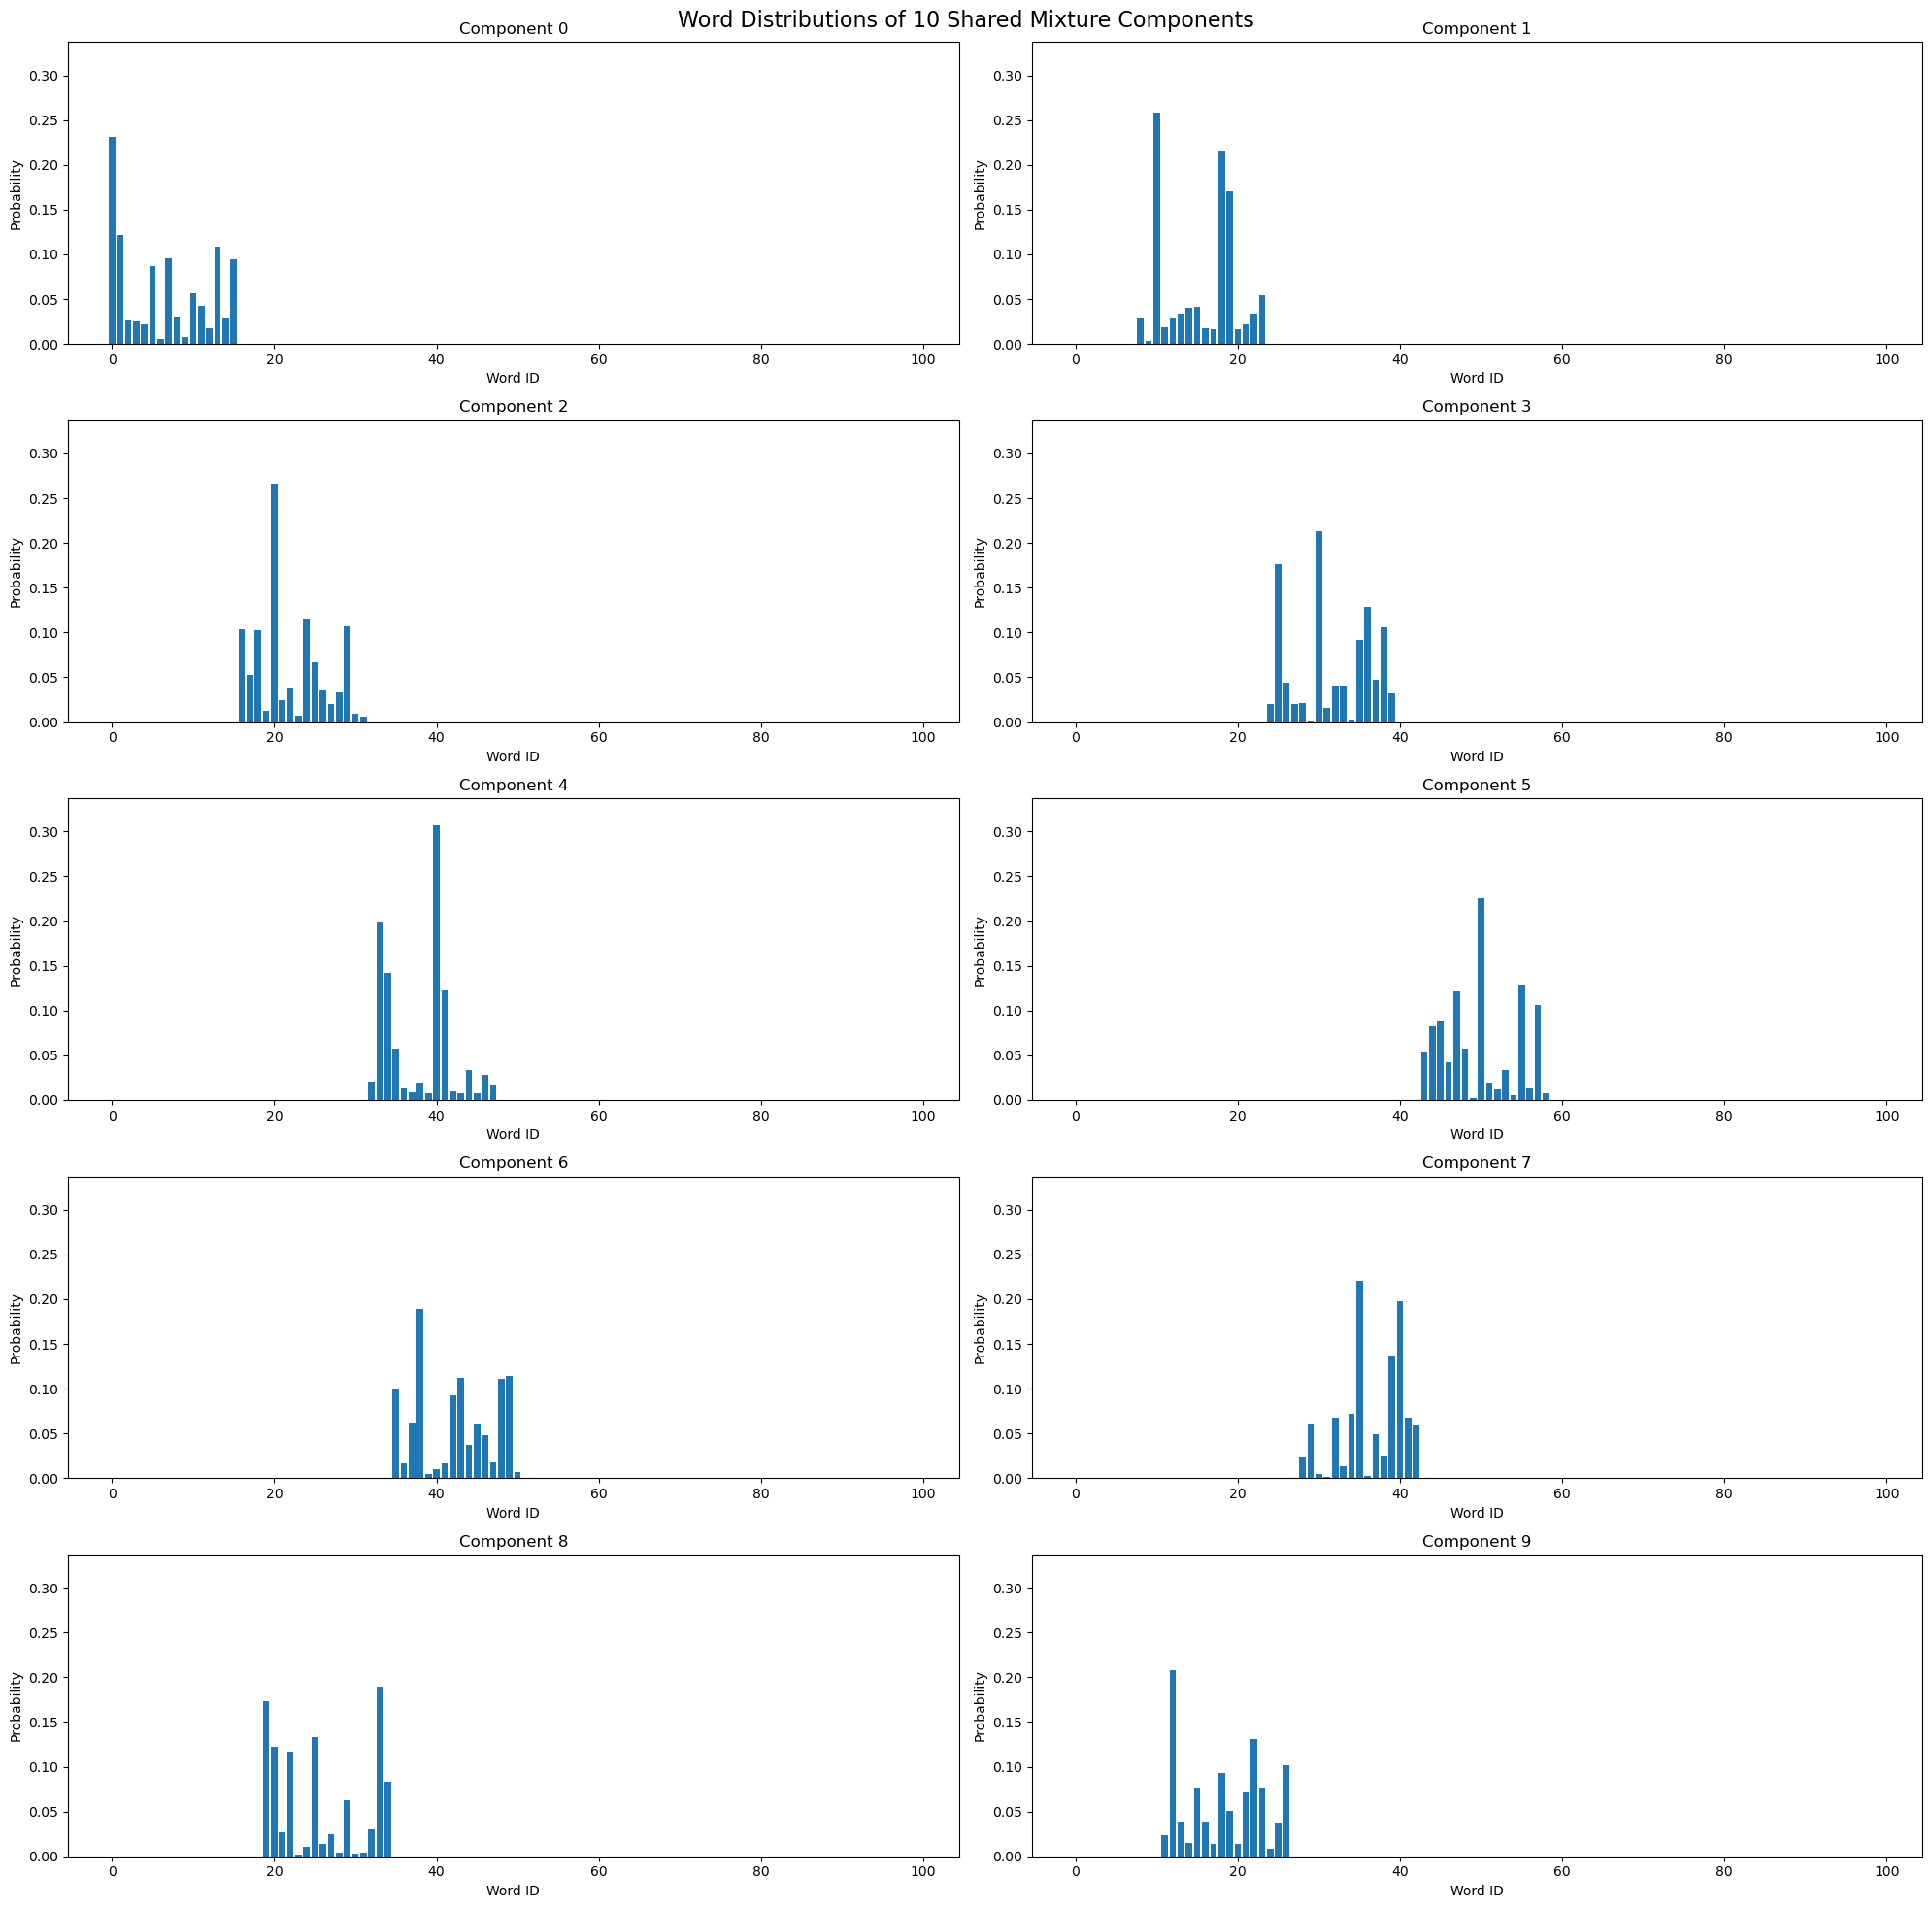

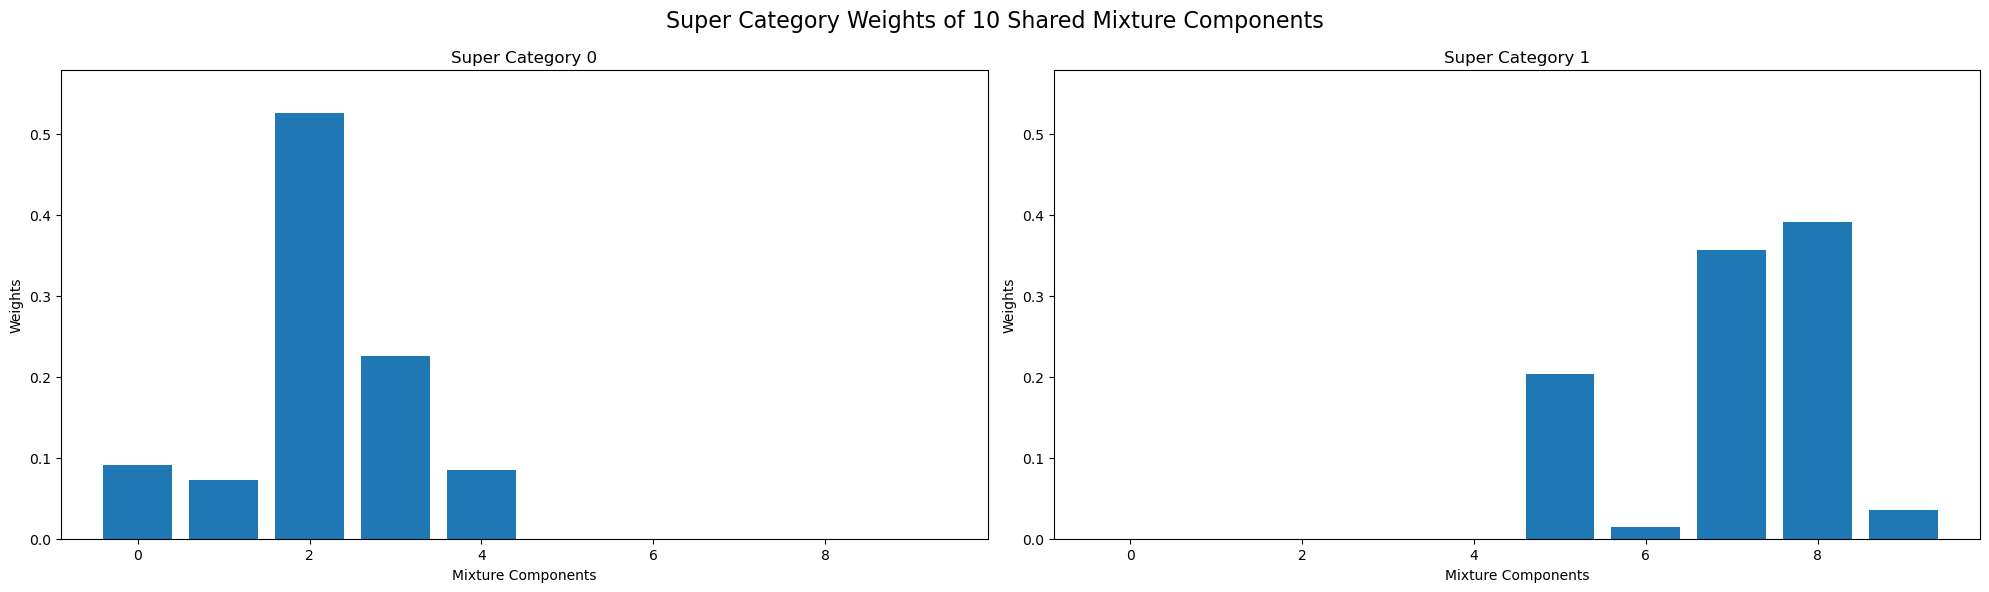

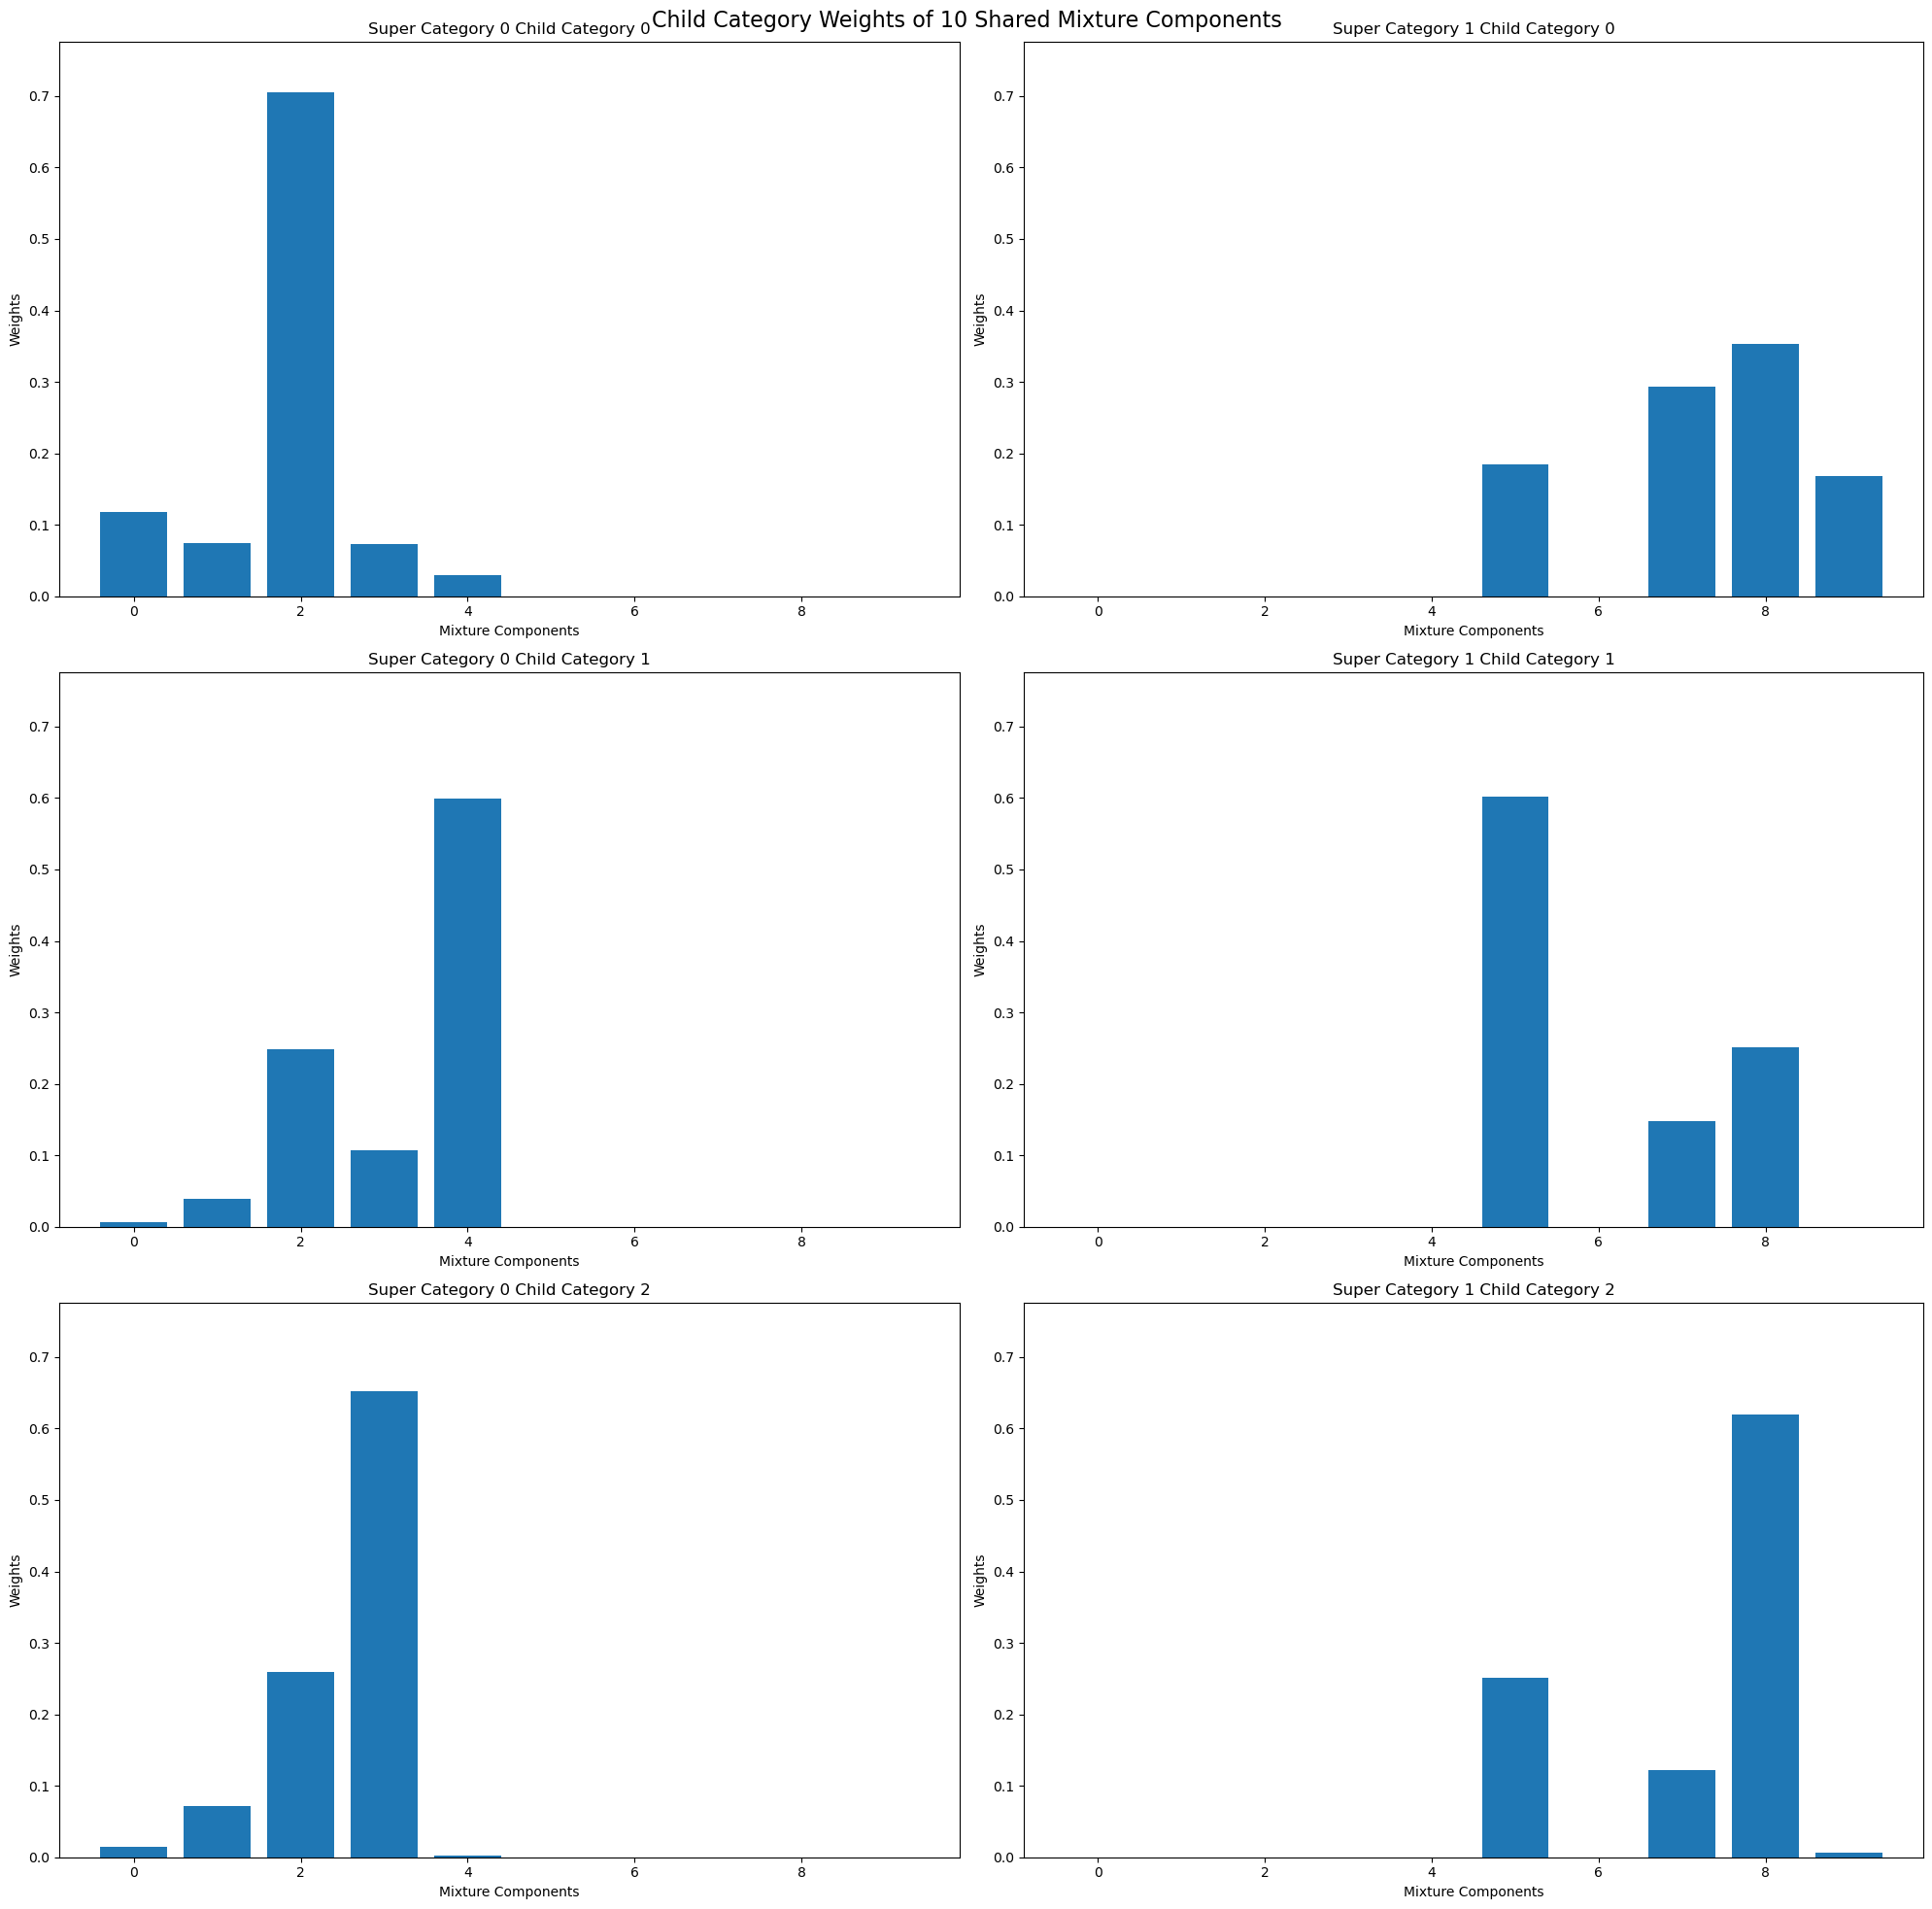

In [15]:
# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# === Mixture Component Word Distributions ===
num_components = 10
V = data["x"].shape[-1]
word_dists = data["word_dists"]
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]
print(child_mix_weights.shape)

# Bar plots for each component
fig, axs = plt.subplots(5, 2, figsize=(20, 20))
for i in range(num_components):
    ax = axs[i // 2, i % 2]
    ax.bar(range(V), word_dists[i].numpy())
    ax.set_title(f"Component {i}")
    ax.set_xlabel("Word ID")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, word_dists.max().item() * 1.1)

fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
for i in range(2):
    ax = axs[i]
    ax.bar(range(10), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(3, 2, figsize=(20, 20))
for i in range(3):
    for j in range(2):
        ax = axs[i, j]
        ax.bar(range(10), child_mix_weights[j][i].numpy())
        ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()


In [16]:
def suffix_sum(x: torch.Tensor) -> torch.Tensor:
    """
    Compute suffix sums along the last dimension of a tensor.
    Each entry is the sum of all elements to its right.
    The last element along that dimension is always 0.
    
    Example:
        x = torch.tensor([1,2,3])
        suffix_sum(x) -> tensor([5,3,0])
        
        x = torch.tensor([[1,2,3],[4,5,6]])
        suffix_sum(x) -> tensor([[5,3,0],
                                  [11,6,0]])
    """
    # Flip along the last dimension
    rev = torch.flip(x, dims=[-1])
    # Cumulative sum on the flipped tensor
    rev_cumsum = torch.cumsum(rev, dim=-1)
    # Flip back
    suffix = torch.flip(rev_cumsum, dims=[-1])
    # Subtract the original to exclude current element
    suffix = suffix - x
    return suffix


In [17]:
def group_sum_general(A: torch.Tensor, B: torch.Tensor, return_counts: bool = False, return_labels: bool = False):
    """
    Grouped sum over the last dimension of B based on categories in A.
    Works with arbitrary integer category labels.

    Args:
        A (torch.Tensor): integer tensor of shape (...,) with category labels.
        B (torch.Tensor): tensor of shape (..., D), aligned with A on all but last dim.
        return_counts (bool): if True, also return counts for each category.
        return_labels (bool): if True, also return the unique category labels.

    Returns:
        sums (torch.Tensor): (num_categories, D) grouped sums.
        counts (torch.Tensor, optional): (num_categories,) counts per category.
        labels (torch.Tensor, optional): (num_categories,) original category labels.
    """
    assert A.shape == B.shape[:-1], "A must align with B on all but last dim"

    # flatten all but last dimension
    A_flat = A.reshape(-1)
    B_flat = B.reshape(-1, B.shape[-1])

    # get unique category labels and map them to [0..K-1]
    labels, inv = torch.unique(A_flat, return_inverse=True)
    num_categories = labels.shape[0]
    device = B.device

    sums = torch.zeros((num_categories, B.shape[-1]), device=device, dtype=B.dtype)
    sums.index_add_(0, inv, B_flat)

    results = (sums,)

    if return_counts:
        counts = torch.bincount(inv, minlength=num_categories).to(device)
        results += (counts,)

    if return_labels:
        results += (labels.to(device),)

    if len(results) == 1:
        return results[0]
    return results


In [18]:
def category_stats_unnormalized(cats: torch.Tensor, vals: torch.Tensor, total_cats: int):
    """
    Compute sum, count, mean, and unnormalized variance sum (no division by n or n-1)
    for all categories from 0 to total_cats-1, including categories not present in cats.
    
    Args:
        cats: Long tensor of shape (N,) with category ids (can be non-consecutive)
        vals: Float tensor of shape (N,) with values corresponding to each entry
        total_cats: total number of categories (0..total_cats-1)
    
    Returns:
        unique_cats: tensor of all categories [0, 1, ..., total_cats-1]
        sums: tensor of sums per category
        counts: tensor of counts per category
        means: tensor of means per category
        unnorm_vars: tensor of unnormalized variance per category
    """
    cats = cats.view(-1)
    vals = vals.view(-1)

    # create tensors for all categories
    sums = torch.zeros(total_cats, dtype=vals.dtype, device=vals.device)
    counts = torch.zeros(total_cats, dtype=torch.long, device=vals.device)
    sq_sums = torch.zeros(total_cats, dtype=vals.dtype, device=vals.device)

    # get unique categories in input
    unique_cats_input, inv_idx = torch.unique(cats, return_inverse=True)

    # accumulate sums, counts, sq_sums for existing categories
    sums.index_add_(0, cats, vals)
    counts.index_add_(0, cats, torch.ones_like(cats, dtype=torch.long))
    sq_sums.index_add_(0, cats, vals * vals)

    # means
    means = sums / counts.clamp(min=1)

    # unnormalized variance
    unnorm_vars = sq_sums - counts.to(vals.dtype) * (means ** 2)

    # final unique_cats is 0..total_cats-1
    unique_cats = torch.arange(total_cats, device=vals.device)

    return unique_cats, sums, counts, means, unnorm_vars


In [19]:
def outer_list(tensors):
    """
    Compute the outer product of a list of 1D tensors.
    Resulting tensor has shape [len(t1), len(t2), ..., len(tn)].
    """
    result = tensors[0]
    for t in tensors[1:]:
        # unsqueeze result and tensor so they can broadcast
        result = result.unsqueeze(-1) * t
    return result


In [83]:
def gibbs_step_for_doc(data_idx, N, M, struct_upbd, model_return, device):

    doc_weights = model_return["doc_weights"]

    # word topic gibbs
    for word_idx in range(M):
        topic_prob = torch.zeros(struct_upbd["G0"], device=device)
        for t in range(struct_upbd["G0"]):
            topic_prob[t] = dist.Multinomial(1, model_return["mixture_components"]["generation"][t]).log_prob(model_return['words']['obs'][data_idx][word_idx].to(torch.long)).exp()*doc_weights["G"][data_idx][t]
        topic_prob = topic_prob / topic_prob.sum()
        topic_prob = torch.clamp(topic_prob, min=1e-6)
        topic_prob = topic_prob / topic_prob.sum()
        new_word_cat = dist.Categorical(probs=topic_prob).sample()
        model_return["words"]["z_gen"][data_idx][word_idx] = new_word_cat

    # Regression component gibbs
    reg_prob = torch.zeros(struct_upbd["G0"], device=device)
    for t in range(struct_upbd["G0"]):
        reg_prob[t] = dist.Normal(model_return["mixture_components"]["regression_mu"][t], model_return["mixture_components"]["regression_sigma"][t]).log_prob(model_return['words']['reg'][data_idx]).exp() * doc_weights["G"][data_idx][t]
    reg_prob = reg_prob / reg_prob.sum()
    reg_prob = torch.clamp(reg_prob, min=1e-6)
    reg_prob = reg_prob / reg_prob.sum()
    new_z_reg = dist.Categorical(probs=reg_prob).sample()
    model_return["words"]["z_reg"][data_idx] = new_z_reg

    # structural component gibbs
    cluster_weights = model_return["cluster_weights"]
    struct_samples = model_return["struct_samples"]
    struct_weights = model_return["struct_weights"]
    
    cat_prob = torch.zeros((struct_upbd["G1"], struct_upbd["G2"]), device=device)
    for s in range(struct_upbd["G1"]):
        for c in range(struct_upbd["G2"]):
            log_cluster_prob = torch.log(cluster_weights["L1"][c, s]) + torch.log(cluster_weights["L0"][s])
            log_struct_prob = torch.sum(dist.Beta(struct_weights["B1"][s][0], struct_weights["B1"][s][1]).log_prob(struct_samples["B1"][s, c]) + dist.Beta(struct_weights["B0"][0], struct_weights["B0"][1]).log_prob(struct_samples["B0"][s]))
            log_doc_prob = torch.sum(dist.Beta(doc_weights["BP"][0][data_idx], doc_weights["BP"][1][data_idx]).log_prob(doc_weights["B"][data_idx]))
            log_word_probs = 0.
            for word_idx in range(M):
                topic_idx = model_return["words"]["z_gen"][data_idx][word_idx]
                log_topic_prob = torch.log(doc_weights["G"][data_idx][topic_idx])
                log_word_prob = dist.Multinomial(1, model_return["mixture_components"]["generation"][topic_idx]).log_prob(model_return['words']['obs'][data_idx][word_idx])
                log_word_probs += log_word_prob + log_topic_prob
            reg_idx = model_return["words"]["z_reg"][data_idx]
            log_reg_topic_prob = torch.log(doc_weights["G"][data_idx][reg_idx])
            log_reg_prob = dist.Normal(model_return["mixture_components"]["regression_mu"][reg_idx], model_return["mixture_components"]["regression_sigma"][reg_idx]).log_prob(model_return['words']['reg'][data_idx])
            cat_prob[s, c] = (log_cluster_prob + log_struct_prob + log_doc_prob + log_word_probs + log_reg_topic_prob + log_reg_prob).exp()
    
    # Step 1: Normalize into probability table
    cat_prob = torch.clamp(cat_prob, min=1e-6)
    z_prob = cat_prob / cat_prob.sum()

    # Step 2: Flatten into 1D for categorical sampling
    z_prob_flat = z_prob.view(-1)

    # Step 3: Sample index from categorical distribution
    z_dist = torch.distributions.Categorical(z_prob_flat)
    sampled_idx = z_dist.sample()  # single index

    # Step 4: Convert flat index back into (row, col)
    row = sampled_idx // cat_prob.size(1)
    col = sampled_idx % cat_prob.size(1)

    model_return["category_assignments"][data_idx] = torch.tensor([row, col])

    # document level distribution
    data_summary = torch.unique(model_return["words"]["z_gen"][data_idx], return_counts=True)
    data_bias = torch.zeros(struct_upbd["G0"], device=device)
    data_bias[data_summary[0]] = data_summary[1].float()
    data_bias[model_return["words"]["z_reg"][data_idx]] += 1.0
    alpha_bias = data_bias
    beta_bias = suffix_sum(data_bias)

    weights_prior = model_return["struct_weights"][f"G{len(struct_upbd)-1}"][col, row]
    concentrate = model_return["struct_params"][f"alpha{len(struct_upbd)-1}"][row, col].unsqueeze(-1)

    param_alpha = concentrate*weights_prior
    param_beta = concentrate*(1 - weights_prior.cumsum(-1))
    beta = dist.Beta(param_alpha + alpha_bias, param_beta + beta_bias).sample()

    model_return["doc_weights"]["B"][data_idx] = beta
    model_return["doc_weights"]["G"][data_idx] = mix_weights(beta)[..., :-1]
    model_return["doc_weights"]["BP"][0][data_idx] = param_alpha + alpha_bias
    model_return["doc_weights"]["BP"][1][data_idx] = param_beta + beta_bias

    return model_return

In [21]:
# def gibbs_step_for_doc(data_idx, N, M, struct_upbd, model_return, device):

#     data_point_cat = model_return["category_assignments"][data_idx]
#     mask = torch.ones(N, device=device, dtype=torch.long)
#     mask[data_idx] = 0

#     # word topic gibbs
#     for word_idx in range(M):
#         word_mask = torch.ones((N, M), device=device, dtype=torch.long)
#         word_mask[data_idx, word_idx] = 0

#         related_word_cat = model_return["words"]["z_gen"] * word_mask
#         related_word_cat = related_word_cat[(model_return["category_assignments"] == data_point_cat).all(dim=1)]
    
#         topic_index, topic_count = torch.unique(related_word_cat, return_counts=True)
#         for idx, val in enumerate(topic_index):
#             if val == 0:
#                 topic_count[idx] -= 1
#         topic_prob = torch.zeros(struct_upbd["G0"], device=device)
#         for t_idx, t_val in enumerate(topic_index):
#             topic_prob[t_val] = topic_count[t_idx] * dist.Multinomial(1, model_return["mixture_components"]["generation"][t_val]).log_prob(model_return['words']['obs'][data_idx][word_idx]).exp()
#         topic_prob = topic_prob / topic_prob.sum()
#         topic_prob = torch.clamp(topic_prob, min=1e-6)
#         topic_prob = topic_prob / topic_prob.sum()
#         new_word_cat = dist.Categorical(probs=topic_prob).sample()
#         model_return["words"]["z_gen"][data_idx][word_idx] = new_word_cat

#     # Regression component gibbs
#     related_reg_cat = model_return["words"]["z_reg"] * mask
#     docs_popu = related_reg_cat[(model_return["category_assignments"] == data_point_cat).all(dim=1)]
#     reg_index, reg_count = torch.unique(docs_popu, return_counts=True)
#     for idx, val in enumerate(reg_index):
#         if val == 0:
#             reg_count[idx] -= 1
#     reg_prob = torch.zeros(struct_upbd["G0"], device=device)
#     for r_idx, r_val in enumerate(reg_index):
#         reg_prob[r_val] = reg_count[r_idx] * dist.Normal(model_return["mixture_components"]["regression_mu"][r_val], model_return["mixture_components"]["regression_sigma"][r_idx]).log_prob(model_return['words']['reg'][data_idx]).exp()
#     reg_prob = reg_prob / reg_prob.sum()
#     reg_prob = torch.clamp(reg_prob, min=1e-6)
#     reg_prob = reg_prob / reg_prob.sum()
#     new_z_reg = dist.Categorical(probs=reg_prob).sample()
#     model_return["words"]["z_reg"][data_idx] = new_z_reg

#     # structural component gibbs
#     related_cat = model_return["category_assignments"] * mask.view(-1, 1)
#     category_assignment = []
#     for level in range(len(struct_upbd)-1):
#         related_level_cat = related_cat[(related_cat[:, :level] == data_point_cat[:level]).all(dim=1)][:, :level+1]
#         masked_category_index, masked_category_count = torch.unique(related_level_cat,  dim=0, return_counts=True)
#         for idx in range(masked_category_index.shape[0]):
#             if masked_category_index[idx][-1].item() == 0:
#                 masked_category_count[idx] -= 1
#         level_prob = torch.zeros(struct_upbd[f"G{level+1}"], device=device)
#         for idx, cat_index in enumerate(masked_category_index):
#             level_prob[cat_index[-1]] = masked_category_count[idx]
#         category_assignment.append(level_prob)
#     cat_prob = outer_list(category_assignment)

#     struct_weights = model_return["struct_weights"]
#     likelihood_term = torch.zeros((struct_upbd["G1"], struct_upbd["G2"]), device=device)
#     for s in range(struct_upbd["G1"]):
#         for c in range(struct_upbd["G2"]):
#             weights = struct_weights[f"G{len(struct_upbd)-1}"][c, s]
#             words_prob = []
#             for m in range(M):
#                 topic_log_prob = dist.Categorical(probs=weights).log_prob(model_return['words']['z_gen'][data_idx][m])
#                 word_log_prob = dist.Multinomial(1, model_return["mixture_components"]["generation"][model_return['words']['z_gen'][data_idx][m]]).log_prob(model_return['words']['obs'][data_idx][m])
#                 words_prob.append(topic_log_prob + word_log_prob)
#             reg_prob = dist.Normal(model_return["mixture_components"]["regression_mu"][model_return['words']['z_reg'][data_idx]], model_return["mixture_components"]["regression_sigma"][model_return['words']['z_reg'][data_idx]]).log_prob(model_return['words']['reg'][data_idx]) + dist.Categorical(probs=weights).log_prob(model_return['words']['z_reg'][data_idx])
#             likelihood_term[s, c] = torch.sum(torch.stack(words_prob)) + reg_prob
#     assert cat_prob.shape == likelihood_term.shape

#     cat_prob = cat_prob * likelihood_term.exp()
#     new_z = torch.zeros(len(struct_upbd)-1, device=device, dtype=torch.long)
#     new_z[0] = dist.Categorical(probs=cat_prob.sum(dim=1).clamp(min=1e-6)/cat_prob.sum().clamp(min=1e-6)).sample()
#     prob = cat_prob[new_z[0]]
#     new_z[1] = dist.Categorical(probs=prob.clamp(min=1e-6)/prob.sum().clamp(min=1e-6)).sample()
#     model_return["category_assignments"][data_idx] = new_z
#     return model_return

In [80]:
def gibbs_sampling(struct_upbd, model_return, vocab_size, iterations, device):

    assert len(model_return["category_assignments"].shape) == 2
    N, M = model_return["words"]["z_gen"].shape
    log_likelihood_trace = []
    log_likelihood_mean = []
    log_likelihood_std = []
    for it in trange(iterations, desc="Gibbs Sampling"):
        category_summary = {}
        for l in range(len(struct_upbd)-1):
            category_index, category_count = torch.unique(model_return["category_assignments"][:, :l+1], dim=0, return_counts=True)
            category_summary[f"level_{l}"] = (category_index, category_count.float())
        components_index, components_count = torch.unique(model_return["words"]["z_gen"], return_counts=True)
        category_summary[f"level_{len(struct_upbd)-1}"] = (components_index, components_count.float())
        components_index, components_count = torch.unique(model_return["words"]["z_reg"],  return_counts=True)
        category_summary[f"level_{len(struct_upbd)}"] = (components_index, components_count.float())

        param_dims = list(struct_upbd.values())
        param_dims.reverse()
        
        # model parameters
        struct_params = model_return["struct_params"]

        # model structures
        struct_weights = {}
        struct_samples = {}
        data_summary = category_summary[f"level_{len(struct_upbd)-1}"]
        data_bias = torch.zeros(struct_upbd["G0"], device=device)
        data_bias[data_summary[0]] = data_summary[1].float()
        alpha_bias = data_bias
        beta_bias = suffix_sum(data_bias)
        param_alpha = torch.ones(1, device=device).expand(param_dims[-1:]) + alpha_bias
        param_beta = struct_params["gamma"].expand(param_dims[-1:]) + beta_bias
        struct_weights["B0"] = (param_alpha, param_beta)
        beta_0 = pyro.sample("G0", dist.Beta(struct_weights["B0"][0], struct_weights["B0"][1]).to_event(1))
        struct_samples["B0"] = beta_0
        assert beta_0.shape == (param_dims[-1], )

        struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
        assert struct_weights["G0"].shape == (param_dims[-1], )

        for parent_level in range(len(struct_upbd)-1):
            child_level = parent_level + 1
            full_dim = child_level + 1
            data_summary = category_summary[f"level_{parent_level}"]
            data_bias = torch.zeros(struct_upbd[f"G{child_level}"], device=device)
            data_bias[data_summary[0]] = data_summary[1].float().unsqueeze(-1)
            alpha_bias = data_bias
            beta_bias = suffix_sum(data_bias)
            shape_adjust =[1] * (parent_level+2)
            shape_adjust[0] = -1
            param_alpha = struct_params[f"alpha{parent_level}"]*struct_weights[f"G{parent_level}"].unsqueeze(0).expand(param_dims[-full_dim:]) + alpha_bias.view(shape_adjust)
            param_beta = struct_params[f"alpha{parent_level}"]*(1 - struct_weights[f"G{parent_level}"].cumsum(-1)).unsqueeze(0).expand(param_dims[-full_dim:]) + beta_bias.view(shape_adjust)
            struct_weights[f"B{child_level}"] = (param_alpha, param_beta)
            beta = pyro.sample(f"G{child_level}", dist.Beta(struct_weights[f"B{child_level}"][0], struct_weights[f"B{child_level}"][1]).to_event(child_level))
            struct_samples[f"B{child_level}"] = beta
            struct_weights[f"G{child_level}"] = mix_weights(beta)[..., :-1]
            assert struct_weights[f"G{child_level}"].shape == tuple(param_dims[-full_dim:])

        model_return["struct_weights"] = struct_weights
        model_return["struct_samples"] = struct_samples

        mixture_components = {}
        data_summary = category_summary[f"level_{len(struct_upbd)-1}"]
        data_bias = torch.zeros(struct_upbd["G0"], device=device)
        data_bias[data_summary[0]] = data_summary[1].float()
        gamma = struct_params["gamma"] * torch.ones(vocab_size, device=device).unsqueeze(0).expand(struct_upbd["G0"], vocab_size) + data_bias.unsqueeze(-1)
        mixture_components["generation"] = pyro.sample(f"gen", dist.Dirichlet(gamma).to_event(1))

        data_summary = category_summary[f"level_{len(struct_upbd)}"]
        data_bias = torch.zeros(struct_upbd["G0"], device=device)

        unique_cats, sums, counts, means, unnorm_vars = category_stats_unnormalized(model_return["words"]["z_reg"], model_return["words"]["reg"], struct_upbd["G0"])

        nig_kappa = torch.zeros(struct_upbd["G0"], device=device)
        nig_kappa[unique_cats] += counts.float()
        nig_kappa += struct_params["nig_kappa"]
        
        nig_mu = torch.zeros(struct_upbd["G0"], device=device)
        nig_mu[unique_cats] += sums*means
        nig_mu += struct_params["nig_kappa"]*struct_params["nig_mu"]
        nig_mu = nig_mu / nig_kappa

        nig_alpha = torch.zeros(struct_upbd["G0"], device=device)
        nig_alpha[unique_cats] += counts/2.
        nig_alpha += struct_params["nig_alpha"]
        
        nig_beta = torch.zeros(struct_upbd["G0"], device=device)
        nig_beta[unique_cats] += struct_params["nig_beta"] + 0.5*unnorm_vars + 0.5*torch.pow((means - struct_params["nig_mu"]), 2)*counts*struct_params["nig_kappa"]/(nig_kappa)

        mixture_components["regression_sigma"] = pyro.sample(f"regression_sigma", dist.InverseGamma(nig_alpha, nig_beta).to_event(1))
        mixture_components["regression_mu"] = pyro.sample(f"regression_mu", dist.Normal(nig_mu, torch.sqrt(mixture_components["regression_sigma"] / nig_kappa)).to_event(1))

        model_return["mixture_components"] = mixture_components
        for data_idx in range(N):
            model_return = gibbs_step_for_doc(data_idx, N, M, struct_upbd, model_return, device)

        if (it % 10 == 0):
            log_likelihood = compute_log_likelihood(model_return)
            log_likelihood_trace.append(log_likelihood)
            if (len(log_likelihood_trace) > 5):
                log_likelihood_trace.pop(0)
                log_likelihood_mean.append(sum(log_likelihood_trace) / 5)
                log_likelihood_std.append(np.std(log_likelihood_trace, ddof=1).item())
        if (it % 100 == 0):
            plt.plot(np.array(log_likelihood_mean))
            plt.fill_between(range(len(log_likelihood_mean)), np.array(log_likelihood_mean) - np.array(log_likelihood_std), np.array(log_likelihood_mean) + np.array(log_likelihood_std), alpha=0.2)
            plt.title(f"Log Likelihood of iteration {it}")
            plt.xlabel("Iterations (x100)")
            plt.ylabel("Log Likelihood")
            plt.show()

            word_dists = model_return["mixture_components"]["generation"]
            # Bar plots for each component
            fig, axs = plt.subplots(5, 2, figsize=(20, 20))
            for i in range(num_components):
                ax = axs[i // 2, i % 2]
                ax.bar(range(V), word_dists[i].detach().numpy())
                ax.set_title(f"Component {i}")
                ax.set_xlabel("Word ID")
                ax.set_ylabel("Probability")
                ax.set_ylim(0, word_dists.max().item() * 1.1)

            fig.suptitle(f"Word Distributions of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()

            super_mix_weights = model_return["struct_weights"]["G1"]
            # Bar plots for each component
            fig, axs = plt.subplots(1, 2, figsize=(20, 6))
            for i in range(2):
                ax = axs[i]
                ax.bar(range(10), super_mix_weights[i].detach().numpy())
                ax.set_title(f"Super Category {i}")
                ax.set_xlabel("Mixture Components")
                ax.set_ylabel("Weights")
                ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

            fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()

            child_mix_weights = model_return["struct_weights"]["G2"]
            # Bar plots for each component
            fig, axs = plt.subplots(3, 2, figsize=(20, 20))
            for i in range(3):
                for j in range(2):
                    ax = axs[i, j]
                    ax.bar(range(10), child_mix_weights[i][j].detach().numpy())
                    ax.set_title(f"Super Category {j} Child Category {i}")
                    ax.set_xlabel("Mixture Components")
                    ax.set_ylabel("Weights")
                    ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

            fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()
            

    return model_return

In [84]:
dataset = (data["x"], data["y"])
vocab_size = data["x"].shape[-1]
device = torch.device("cpu")
hdmm = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, device="cpu")

In [85]:
model_return = gibbs_sampling(struct_upbd, hdmm, vocab_size, iterations=1000, device=device)

Gibbs Sampling:   0%|          | 0/1000 [03:09<?, ?it/s]


KeyboardInterrupt: 